# 09 — A controlled feature study

**Question.** Can broad feature engineering improve a compact ranker when the candidate pool,
historical cutoff, fitting sample, and evaluation cohort are held fixed?

**Result.** The selected 102-feature model achieves **0.58439 weighted Recall@20** on
**432,492 temporal evaluation sessions**. The compact 28-feature model scores **0.56490**;
fixed candidate fusion scores **0.53524**. Selection preferred removing source-score features.
Orders drive the gain; fusion still wins click and cart recall.

This notebook regenerates every chart from checksum-verified, committed evidence. Model fitting
and the independent event audit ran separately at full scale. [Notebook 10](10_competition_inference.ipynb)
runs native models and generates predictions. [Methods](../docs/RESEARCH.md) ·
[Machine-readable catalog](../reports/research/feature_catalog.csv) ·
[Independent audit](../reports/research/audit.json)

In [1]:
from pathlib import Path
import hashlib
import json
import math
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'reports/research/manifest.json').is_file())
DATA = ROOT / 'reports/research'
load = lambda name: json.loads((DATA / name).read_text())
manifest = load('manifest.json')
for name, expected in manifest['files'].items():
    assert hashlib.sha256((DATA / name).read_bytes()).hexdigest() == expected, name
evaluation, ablations = load('evaluation.json'), load('ablations.json')
audit, interpretation = load('audit.json'), load('interpretation.json')
screening, seal = load('screening.json'), load('evaluation_seal.json')
assert len({x['seal_id'] for x in (manifest, evaluation, audit, interpretation, seal)}) == 1
assert audit['status'] == evaluation['status'] == interpretation['status'] == 'passed'
assert seal['evaluation_labels_consulted'] is False
catalog = pd.read_csv(DATA / 'feature_catalog.csv')
families = pd.read_csv(DATA / 'feature_families.csv')
models = pd.read_csv(DATA / 'ablation_models.csv')
importance = pd.read_csv(DATA / 'feature_importance.csv')
COLORS = {'selected': '#0F766E', 'core': '#2563EB', 'fusion': '#64748B', 'ceiling': '#D97706'}
pio.renderers.default = 'plotly_mimetype+png'

def show(fig, title, height=480, left=90):
    fig.update_layout(template='plotly_white', width=1000, height=height,
        title=dict(text=title, x=0.03), font=dict(family='Arial', size=14, color='#1E293B'),
        margin=dict(l=left, r=40, t=85, b=70), paper_bgcolor='white', plot_bgcolor='white',
        legend=dict(orientation='h', y=1.12, x=0), hoverlabel=dict(font_size=14))
    fig.show()

print(f"Verified {len(manifest['files'])} evidence files; evaluation seal {seal['seal_id'][:12]}.")

Verified 21 evidence files; evaluation seal 0b77504da3e1.


## Freeze time before choosing models

Every learned retrieval component in this study is newly fitted on events before **20 August 2022,
22:00 UTC**. Whole sessions are assigned by their first event, clipped at exclusive period ends,
and cut into observed prefixes and future targets without using labels for inclusion. Fit and
selection session samples use deterministic hashes; evaluation includes every eligible session.

The original OTTO data had earlier exploratory exposure. This is a **newly reserved temporal
evaluation**, not a claim that the underlying data had never been seen. The earlier neural and
Item2Vec artifacts are not reused in this controlled comparison.

In [2]:
protocol = load('temporal_contract.json')['protocol']
periods = pd.DataFrame([
    ['Historical retrieval', 'before 2022-08-20 22:00 UTC', 'all permitted history'],
    ['Ranker fit', '2022-08-20 → 2022-08-23, 22:00 UTC', f"{audit['source']['roles']['fit']:,} sessions"],
    ['Model selection', '2022-08-23 → 2022-08-24, 22:00 UTC', f"{audit['source']['roles']['selection']:,} sessions"],
    ['Final evaluation', '2022-08-24 → 2022-08-26, 22:00 UTC', f"{evaluation['sessions']:,} sessions"],
], columns=['Role', 'Time boundary', 'Size'])
display(periods.style.hide(axis='index'))
assert all(v == 0 for v in audit['source']['differences'].values())
assert audit['native_replay']['mismatches'] == 0
print(f"Independent audit: {audit['source']['source_partitions']} original Parquet partitions; "
      f"{audit['source']['reconstructed_labels']:,} reconstructed targets; "
      f"{audit['native_replay']['comparisons']:,} sampled native-model/candidate checks; zero differences.")

Role,Time boundary,Size
Historical retrieval,before 2022-08-20 22:00 UTC,all permitted history
Ranker fit,"2022-08-20 → 2022-08-23, 22:00 UTC","100,000 sessions"
Model selection,"2022-08-23 → 2022-08-24, 22:00 UTC","20,000 sessions"
Final evaluation,"2022-08-24 → 2022-08-26, 22:00 UTC","432,492 sessions"


Independent audit: 217 original Parquet partitions; 788,883 reconstructed targets; 4,608 sampled native-model/candidate checks; zero differences.


## Engineer broadly; retain evidence of value

The catalog spans historical popularity/trends, observed recurrence and intent, source agreement,
session context, and action/time-weighted graph affinity. Its 1,482 entries are explicit formulas,
not identifiers or future-label features. A broad catalog is a search space, not a result by itself.

Screening uses **514,013 candidate rows from 8,448 fitting sessions**. Constant, near-constant, and
duplicate columns are removed first. Nine binary LightGBM pilots—three objectives across three
session-grouped folds—supply normalized gain and stability diagnostics. Protected compact features,
redundancy filtering, and a 128-column capacity limit define the shortlist. Binary log loss and
feature/target correlations are screening diagnostics, not Recall@20 estimates.

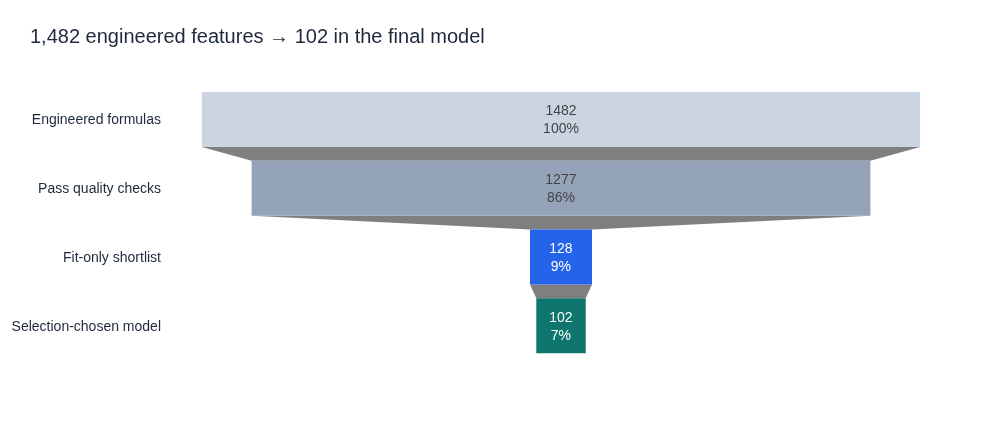

Family,Engineered,Shortlist,Final
context,24,19,19
graph,1152,5,5
history,99,57,57
interaction,11,4,4
repeat,160,17,17
source,36,26,0


Reason,Features
capacity,1118
constant,54
duplicate,146
near_constant,5
redundant,31


family,median_fold_stability,minimum_fold_stability
context,1.000,1.000
graph,1.000,0.667
history,1.000,1.000
interaction,1.000,1.000
repeat,1.000,0.333
source,1.000,1.000


In [3]:
eligible = len(catalog) - sum(screening['rejections'][k] for k in ('constant', 'near_constant', 'duplicate'))
fig = go.Figure(go.Funnel(y=['Engineered formulas', 'Pass quality checks', 'Fit-only shortlist', 'Selection-chosen model'],
    x=[len(catalog), eligible, screening['retained_count'], int(catalog['final_selected'].sum())],
    textinfo='value+percent initial', marker=dict(color=['#CBD5E1', '#94A3B8', '#2563EB', '#0F766E'])))
show(fig, '1,482 engineered features → 102 in the final model', 430)
display(families.rename(columns={'family':'Family', 'engineered':'Engineered', 'screened':'Shortlist', 'final':'Final'})
        .style.hide(axis='index'))
rejected = pd.DataFrame([{'Reason': k, 'Features': v} for k, v in screening['rejections'].items() if k != 'retained'])
display(rejected.style.hide(axis='index'))
retained = catalog[catalog['status'] == 'retained']
display(retained.groupby('family', as_index=False).agg(
    median_fold_stability=('positive_gain_fold_fraction', 'median'),
    minimum_fold_stability=('positive_gain_fold_fraction', 'min')).style.format(precision=3).hide(axis='index'))

## Test the shortlist under a matched ranking experiment

Eight variants × three objectives = **24 LambdaRank fits**. Every variant uses the same
100,000 fitting sessions, 400-candidate pools, and retained positives plus the same 30 hard/30
random fitting negatives. All 20,000 selection queries keep the full candidate pool and complete
target denominators. Selection maximizes official task Recall@20; fewer features, then name,
break ties. Checkpoints are measured at iteration 1 and every 5 rounds, with early stopping.

Removing the 26 shortlisted source-score features wins all three objectives in selection.
Graph and intent interactions still encode retrieval information; this ablation isolates the
direct source family. This is a useful negative result: screening importance did not guarantee ranking utility.
The other five families remain, giving **102 features**. Family comparisons are exploratory
model-selection evidence; their maximum is not an unbiased performance estimate.

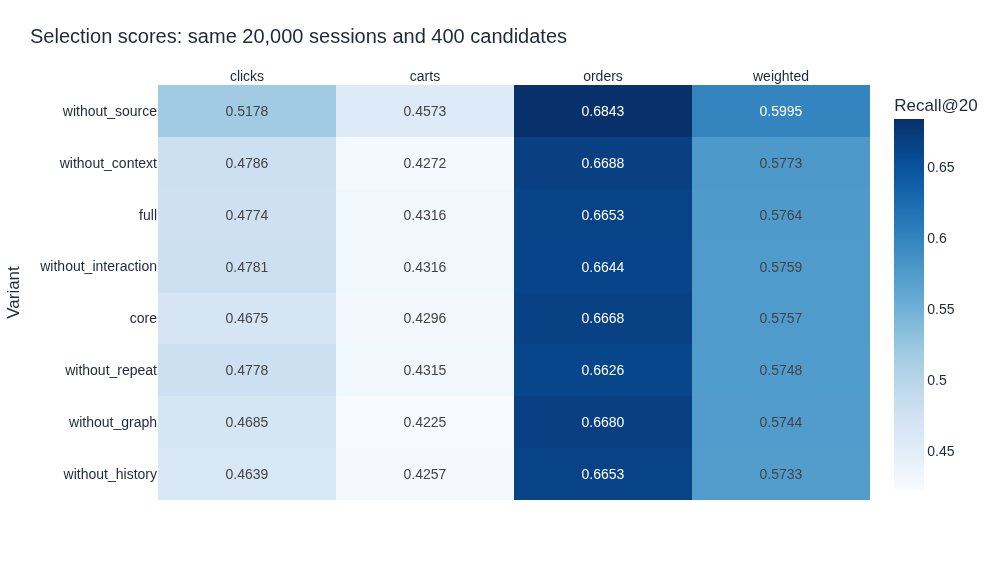

objective,variant,features,best_iteration,fit_seconds
carts,without_source,102,60,28.51
clicks,without_source,102,40,24.26
orders,without_source,102,95,35.87


All model choices were sealed before evaluation labels were opened.


In [4]:
selection = pd.DataFrame({name: {**{o: row['objectives'][o]['recall_at_20'] for o in ('clicks','carts','orders')},
    'weighted': row['weighted_recall_at_20']} for name,row in ablations['variants'].items()}).T
selection = selection.sort_values('weighted', ascending=False)
fig = px.imshow(selection, text_auto='.4f', aspect='auto', color_continuous_scale='Blues',
    labels=dict(x='Objective', y='Variant', color='Recall@20'))
fig.update_xaxes(side='top', title_text=None)
show(fig, 'Selection scores: same 20,000 sessions and 400 candidates', 570)
display(models[models['chosen']][['objective','variant','features','best_iteration','fit_seconds']]
    .sort_values('objective').style.format({'fit_seconds':'{:.2f}'}).hide(axis='index'))
assert set(ablations['chosen'].values()) == {'without_source'}
assert all(seal['models'][o]['variant'] == ablations['chosen'][o] for o in ablations['chosen'])
print('All model choices were sealed before evaluation labels were opened.')

## Evaluate once, with every eligible query in the denominator

The competition metric pools hits and unique-target denominators capped at 20 within each
objective, then applies weights **0.10 / 0.30 / 0.60**. Unretrievable targets remain in the
denominator. Click targets are the next click; carts and orders are unique future items.

The selected model improves the compact ranker by **1.949 percentage points** and fusion by
**4.915 points**. The paired 95% bootstrap intervals exclude zero. These intervals resample
sessions within this frozen model/cohort; they do not include training-seed uncertainty or
uncertainty from the search over model variants.

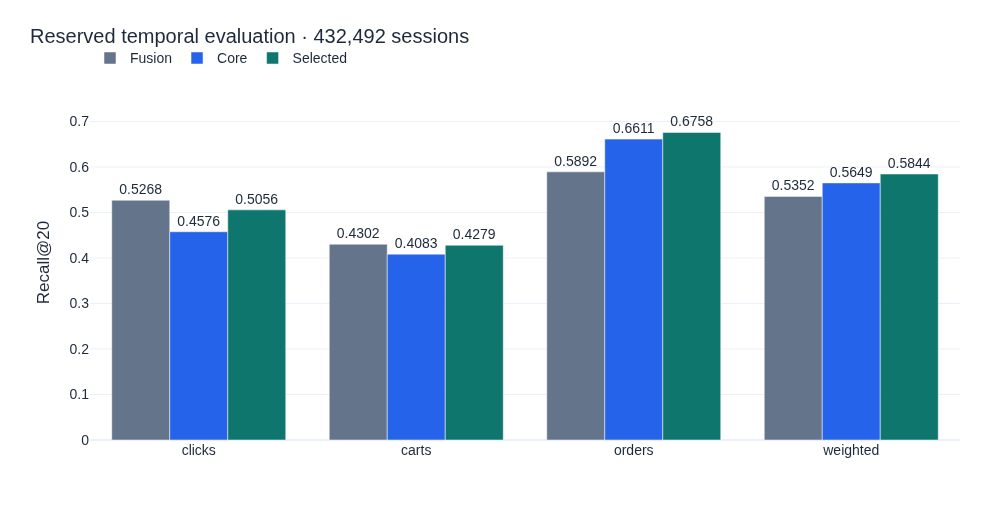

Comparison,Gain (pp),95% lower (pp),95% upper (pp)
Selected − core,1.949,1.840,2.065
Selected − fusion,4.915,4.697,5.136


1,000 paired session bootstrap replicates; seed 20260908.


In [5]:
scores = pd.DataFrame({name: {**{o: row['objectives'][o]['recall_at_20'] for o in ('clicks','carts','orders')},
    'weighted': row['weighted_recall_at_20']} for name,row in evaluation['scores'].items()})
for name,row in evaluation['scores'].items():
    recomputed = sum(w * row['objectives'][o]['hits'] / row['objectives'][o]['denominator']
        for o,w in {'clicks':.1,'carts':.3,'orders':.6}.items())
    assert math.isclose(recomputed, row['weighted_recall_at_20'], abs_tol=1e-12)
fig = go.Figure()
for name in ('fusion','core','selected'):
    fig.add_bar(name=name.capitalize(), x=scores.index, y=scores[name], marker_color=COLORS[name],
        text=scores[name].map(lambda x: f'{x:.4f}'), textposition='outside')
fig.update_layout(barmode='group')
fig.update_yaxes(title='Recall@20', range=[0,.78])
show(fig, f"Reserved temporal evaluation · {evaluation['sessions']:,} sessions", 510)
gain_rows = []
for baseline, result in evaluation['paired_intervals'].items():
    gain_rows.append({'Comparison': f'Selected − {baseline}', 'Gain (pp)': 100*result['absolute_gain'],
        '95% lower (pp)':100*result['gain_interval'][0], '95% upper (pp)':100*result['gain_interval'][1]})
display(pd.DataFrame(gain_rows).style.format(precision=3).hide(axis='index'))
print('1,000 paired session bootstrap replicates; seed 20260908.')

**What did not improve?** Fusion still beats the selected model on clicks (0.52678 vs 0.50565)
and carts (0.43021 vs 0.42792). Orders improve from 0.58917 to 0.67575 and carry 60% of the official
metric. No post-evaluation hybrid was selected to hide those losses. The old Fold 0 score in
Notebook 08 uses a different cohort and pool; it is not a matched baseline for this study.

## Separate candidate coverage from ranking quality

The same nested 100/200/400-item pools have weighted candidate ceilings of 0.65603 / 0.67497 /
0.68695. A ceiling counts recoverable targets with an ideal ordering, capped at 20; it is not an
achieved prediction score. All learned comparisons above use 400 candidates. These curves do not
claim that a ranker was refitted at each smaller budget or that larger pools have free compute cost.

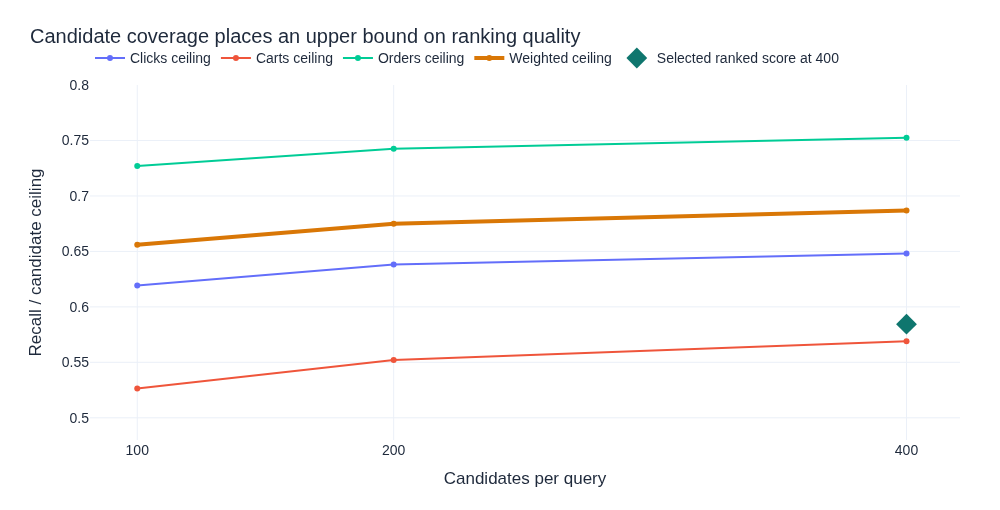

In [6]:
budgets = [100,200,400]
fig = go.Figure()
for objective in ('clicks','carts','orders'):
    y = [evaluation['candidate_frontier'][str(k)]['objectives'][objective]['recall_at_20'] for k in budgets]
    fig.add_scatter(name=objective.capitalize()+' ceiling', x=budgets, y=y, mode='lines+markers')
fig.add_scatter(name='Weighted ceiling', x=budgets,
    y=[evaluation['candidate_frontier'][str(k)]['weighted_recall_at_20'] for k in budgets],
    mode='lines+markers', line=dict(color=COLORS['ceiling'], width=4))
fig.add_scatter(name='Selected ranked score at 400', x=[400],
    y=[evaluation['scores']['selected']['weighted_recall_at_20']], mode='markers',
    marker=dict(color=COLORS['selected'], size=16, symbol='diamond'))
fig.update_xaxes(title='Candidates per query', tickvals=budgets)
fig.update_yaxes(title='Recall / candidate ceiling', range=[.48,.80])
show(fig, 'Candidate coverage places an upper bound on ranking quality', 510)

## Explain the frozen model without reopening selection

Native LightGBM TreeSHAP explains raw ranking scores on **4,096 deterministic selection
candidate rows**. Additivity is checked against native model outputs; the largest absolute error
is below 6 × 10⁻¹⁵. These contributions are not calibrated probabilities or causal effects.
Each panel uses its own objective's score scale.

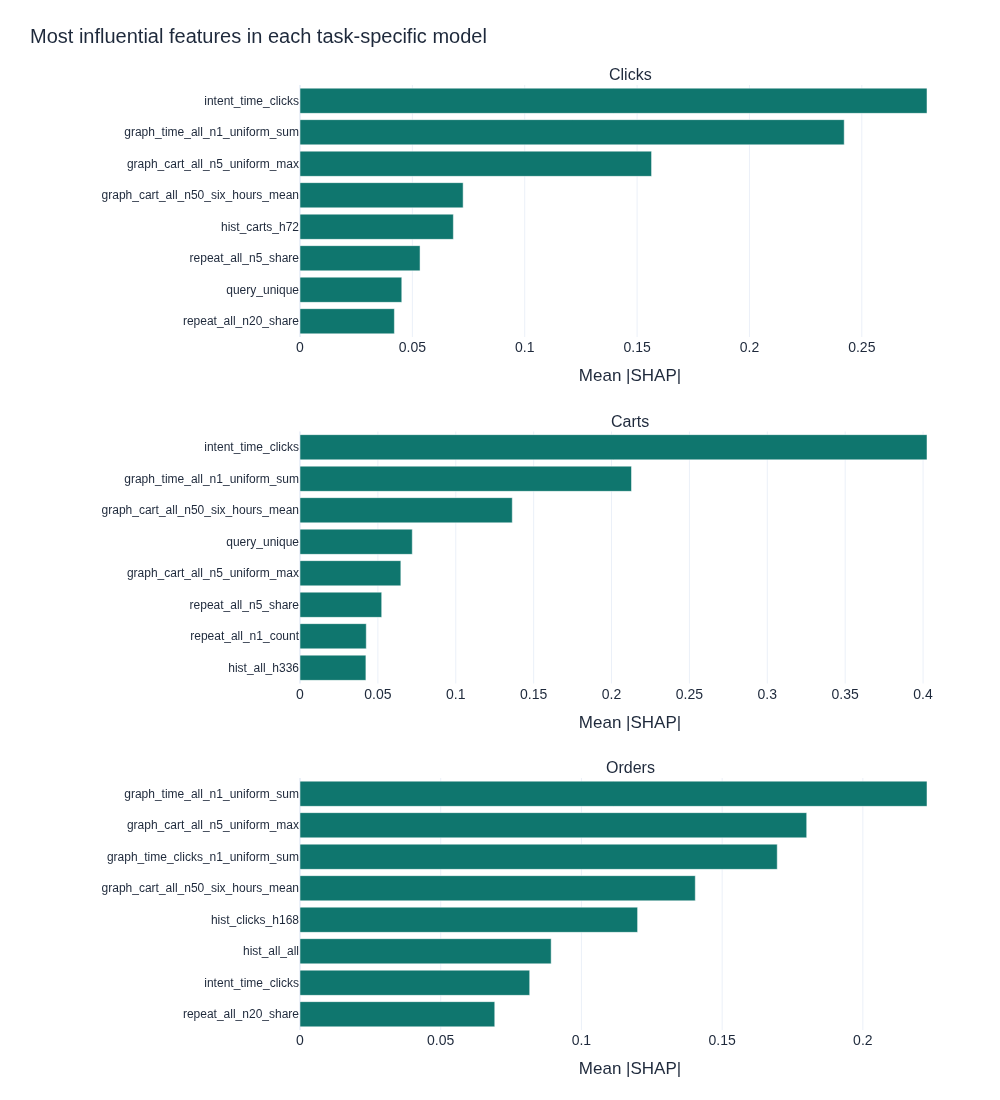

Objective,Maximum additivity error
carts,4.88e-15
clicks,3.55e-15
orders,5.55e-15


In [7]:
fig = make_subplots(rows=3, cols=1, subplot_titles=['Clicks','Carts','Orders'], vertical_spacing=.10)
for row, objective in enumerate(('clicks','carts','orders'), 1):
    top = importance[importance['objective'] == objective].nlargest(8, 'mean_absolute_shap').sort_values('mean_absolute_shap')
    fig.add_bar(x=top['mean_absolute_shap'], y=top['feature'], orientation='h', row=row, col=1,
        marker_color=COLORS['selected'], showlegend=False,
        hovertemplate='%{y}<br>Mean |SHAP|: %{x:.5f}<extra></extra>')
    fig.update_yaxes(tickfont=dict(size=12), row=row, col=1)
    fig.update_xaxes(title='Mean |SHAP|', row=row, col=1)
show(fig, 'Most influential features in each task-specific model', 1100, left=300)
display(pd.DataFrame([{'Objective': o, 'Maximum additivity error': e}
    for o,e in interpretation['shap_additivity_max_abs_error'].items()])
    .style.format({'Maximum additivity error':'{:.2e}'}).hide(axis='index'))

Whole-query block permutation complements feature-level SHAP. Each family is shuffled twice
across **1,000 selection sessions**, preserving relationships within the family. Candidate/feature
dependencies can still be broken, so the measured recall drop is a diagnostic. Two shuffles are
not a confidence interval. Context-only columns are constant within a query and can have little
direct ranking effect while interacting with item features.

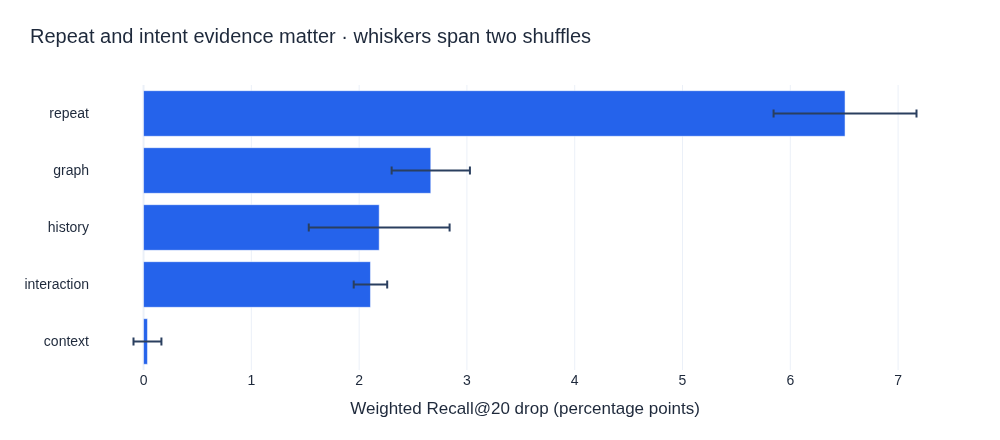

Diagnostic sample: 1,000 sessions, 400,000 candidate rows; weighted recall 0.55937.


In [8]:
permutations = pd.DataFrame([{'family': family, 'mean': row['mean_weighted_recall_drop'],
    'minimum': min(row['repeat_drops']), 'maximum': max(row['repeat_drops'])}
    for family,row in interpretation['group_permutation'].items()]).sort_values('mean')
fig = go.Figure(go.Bar(x=permutations['mean']*100, y=permutations['family'], orientation='h',
    marker_color=COLORS['core'], error_x=dict(type='data', symmetric=False,
        array=(permutations['maximum']-permutations['mean'])*100,
        arrayminus=(permutations['mean']-permutations['minimum'])*100)))
fig.update_xaxes(title='Weighted Recall@20 drop (percentage points)')
show(fig, 'Repeat and intent evidence matter · whiskers span two shuffles', 440)
print(f"Diagnostic sample: {interpretation['selection_sessions']:,} sessions, "
      f"{interpretation['candidate_rows']:,} candidate rows; weighted recall {interpretation['sample_score']['weighted_recall_at_20']:.5f}.")

## Measure feature cost on identical work

The benchmark uses the same 32 selection prefixes and 400-candidate policy for every feature
set. The first pass warms the engine; two measured passes provide 64 query timings. It includes
candidate generation and requested feature construction in one process. It excludes model
prediction, storage/network overhead, and online serving. The hardware is a SageMaker
**ml.c7i.16xlarge (64 logical CPUs, approximately 124 GiB available RAM)**.

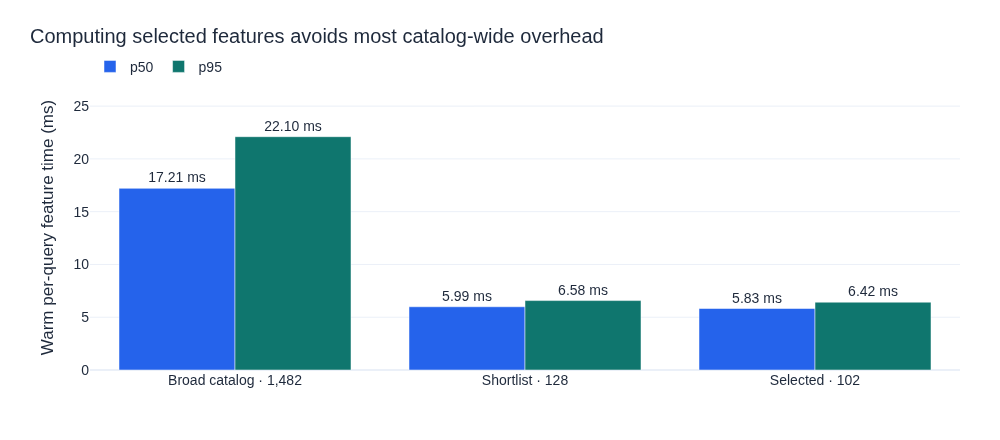

Single-process warm candidate generation plus features, same selection prefixes and 400-item budget; no network or serving latency claim.


In [9]:
timing = pd.DataFrame(interpretation['feature_benchmark']).T
labels = ['Broad catalog · 1,482','Shortlist · 128','Selected · 102']
fig = go.Figure()
for metric, color in [('p50_ms', COLORS['core']), ('p95_ms', COLORS['selected'])]:
    values = timing.loc[['broad_catalog','screened','selected_models'], metric]
    fig.add_bar(x=labels, y=values, name=metric.replace('_ms',''), marker_color=color,
        text=values.map(lambda x:f'{x:.2f} ms'), textposition='outside')
fig.update_layout(barmode='group')
fig.update_yaxes(title='Warm per-query feature time (ms)', range=[0,27])
show(fig, 'Computing selected features avoids most catalog-wide overhead', 440)
print(interpretation['benchmark_scope'])

## Inspect failures and set the limits of the claim

Short prefixes dominate the query count. The overall weighted metric pools task denominators;
it is not an unweighted average of the slice scores. In the 2–5-event slice the selected model
slightly loses to fusion, despite improving the overall result. Longer-session orders explain
much of the advantage. This is diagnostic analysis after the model was frozen, not another
model-selection pass.

In [10]:
slices = []
for label in ('1','2-5','6-20','21+'):
    row = evaluation['prefix_slices'][label]
    slices.append({'Observed events':label, 'Sessions':row['sessions'],
        **{name:row[name]['weighted_recall_at_20'] for name in ('fusion','core','selected')}})
display(pd.DataFrame(slices).style.format({'Sessions':'{:,}', 'fusion':'{:.5f}', 'core':'{:.5f}', 'selected':'{:.5f}'}).hide(axis='index'))
checks = pd.DataFrame([
    ['Target reconstruction', f"{audit['source']['reconstructed_labels']:,} labels; zero differences"],
    ['Metric coverage', f"{audit['statistics']['parts']} parts; {audit['statistics']['sessions']:,} sessions"],
    ['Model selection', f"{audit['ablations']['native_models']} native models; predeclared rule verified"],
    ['Prediction replay', f"{audit['native_replay']['comparisons']:,} independent checks; zero differences"],
    ['Raw conversion provenance', 'Original raw JSONL identity retained; conversion not independently replayed'],
], columns=['Audit', 'Evidence'])
display(checks.style.hide(axis='index'))

Observed events,Sessions,fusion,core,selected
1,"203,352",0.55681,0.52996,0.55799
2-5,"160,332",0.59972,0.57458,0.59704
6-20,"58,470",0.51395,0.54238,0.55882
21+,"10,338",0.37769,0.54774,0.55732


Audit,Evidence
Target reconstruction,"788,883 labels; zero differences"
Metric coverage,"423 parts; 432,492 sessions"
Model selection,24 native models; predeclared rule verified
Prediction replay,"4,608 independent checks; zero differences"
Raw conversion provenance,Original raw JSONL identity retained; conversion not independently replayed


## What this establishes

The selected representation improves the compact ranking control in all nine audited runs across three temporal windows and three training seeds. The original reference result is 0.584392 weighted Recall@20. Matched gains range from +1.791 to +2.180 percentage points, and every paired 95% session-bootstrap interval is above zero.

All nine selection procedures choose the variant without direct source-score features for clicks, carts and orders. Retrieval still generates the candidates; graph and intent features retain indirect retrieval information. This repeated negative ablation is evidence for simplifying the ranker.

The study supports reproducible offline gains on this historical dataset. It does not establish online business lift, causal feature effects or state-of-the-art performance. Earlier neural benchmarks use different protocols. [Notebook 10](10_competition_inference.ipynb) demonstrates official-prefix inference with the original frozen reference weights and records the Kaggle submission state.


## Completed robustness extension

The frozen protocol repeated the complete procedure across **three windows × three model seeds**. Earlier windows built retrieval from permitted history and screened features using only their fitting cohorts. Seeds within a window share the prepared inputs; only the model seed changes.

**All nine cells are independently audited.** The table includes every planned outcome. These are saved verified results, not a live cloud dashboard.


In [11]:
import tomllib

robustness = json.loads((ROOT / 'reports/robustness/progress.json').read_text())
robustness_plan = tomllib.loads((ROOT / 'configs/robustness.toml').read_text())
expected_plan = hashlib.sha256(json.dumps(robustness_plan, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()
assert robustness['protocol_id'] == expected_plan, 'Stale robustness protocol'
expected_cells = {f"{w['name']}_seed_{s}" for w in robustness_plan['windows'] for s in robustness_plan['model_seeds']}
assert {r['cell_id'] for r in robustness['cells']} == expected_cells
reference_cell = next(r for r in robustness['cells'] if r['cell_id'] == 'reference_seed_20260908')
assert reference_cell['weighted_recall_at_20'] == evaluation['scores']['selected']['weighted_recall_at_20']
assert all(r['weighted_recall_at_20'] is None for r in robustness['cells'] if r['status'] in {'planned', 'running'})
progress_table = pd.DataFrame(robustness['cells'])[['window', 'model_seed', 'status', 'weighted_recall_at_20']]
progress_table.columns = ['Temporal window', 'Model seed', 'Observed state', 'Weighted Recall@20']
progress_table['Observed state'] = progress_table['Observed state'].replace({'verified_reference': 'Verified reference', 'verified': 'Verified replication', 'running': 'Running; score pending', 'planned': 'Planned'})
display(progress_table.style.format({'Model seed': '{:.0f}', 'Weighted Recall@20': '{:.6f}'}, na_rep='Pending').hide(axis='index'))
print(f"Status observed at {robustness['observed_at_utc']}. This is saved execution evidence, not a live AWS dashboard.")
print(f"Verified full submission files: {robustness['verified_full_submissions']}; valid Kaggle scores recorded: {robustness['valid_kaggle_scored_submissions']}.")


Temporal window,Model seed,Observed state,Weighted Recall@20
early,20260908,Verified replication,0.566897
early,20260909,Verified replication,0.566784
early,20260910,Verified replication,0.566465
middle,20260908,Verified replication,0.590759
middle,20260909,Verified replication,0.590745
middle,20260910,Verified replication,0.590465
reference,20260908,Verified reference,0.584392
reference,20260909,Verified replication,0.584430
reference,20260910,Verified replication,0.584988


Status observed at 2026-09-09T23:49:34.868965+00:00. This is saved execution evidence, not a live AWS dashboard.
Verified full submission files: 1; valid Kaggle scores recorded: 1.


## Does the feature gain repeat across time and training seeds?

**Yes, within this frozen study.** All nine selected rankers beat their matched compact controls. Gains range from **+1.791 to +2.180 percentage points**. The all-seed score ranges are **0.566465–0.566897** for the early window, **0.590465–0.590759** for the middle window, and **0.584392–0.584988** for the reference window.

The highest absolute offline score is **0.590759**, middle window seed **20260908**. Within the reference cohort, seed **20260910** is highest at **0.584988**. Different windows contain different sessions, so these maxima are descriptive; they do not identify a universally better model. The original reference seed **20260908** remains frozen for submission with its **0.584392** evaluation. No seed is selected using reserved evaluation outcomes.

The error bars are paired 95% session-bootstrap intervals conditional on each fitted model pair. Seeds within a window share their evaluation sessions and must not be pooled as independent observations. Earlier histories overlap and the checks are retrospective.

The original events, every reserved-session metric, 24 native models and eight ablations per replication, sampled model replay, and both 1,000-resample bootstrap comparisons were independently checked. The raw JSONL conversion was not replayed. Full model, per-objective and feature-selection details remain in the tables below.


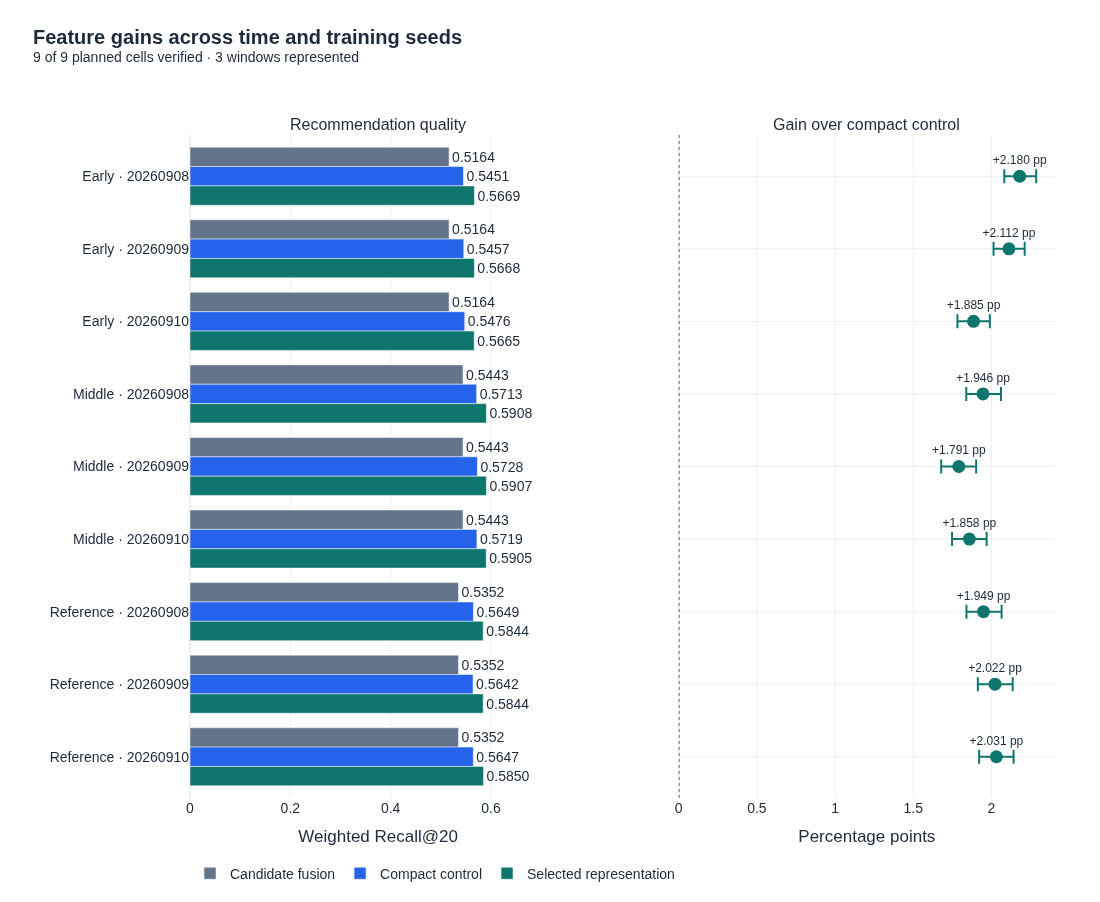

Window,Seed,Sessions,fusion,core,selected,Gain (pp),95% lower (pp),95% upper (pp)
early,20260908,"562,504",0.516428,0.545094,0.566897,+2.180,+2.082,+2.286
early,20260909,"562,504",0.516428,0.545668,0.566784,+2.112,+2.013,+2.212
early,20260910,"562,504",0.516428,0.547613,0.566465,+1.885,+1.782,+1.989
middle,20260908,"488,504",0.544264,0.571302,0.590759,+1.946,+1.839,+2.061
middle,20260909,"488,504",0.544264,0.572832,0.590745,+1.791,+1.678,+1.902
middle,20260910,"488,504",0.544264,0.571880,0.590465,+1.858,+1.748,+1.969
reference,20260908,"432,492",0.535244,0.564904,0.584392,+1.949,+1.840,+2.065
reference,20260909,"432,492",0.535244,0.564207,0.584430,+2.022,+1.913,+2.135
reference,20260910,"432,492",0.535244,0.564675,0.584988,+2.031,+1.921,+2.141


Window,Seed,Objective,fusion,core,selected,Chosen variant,Features
early,20260908,clicks,0.526940,0.455046,0.507496,without_source,101
early,20260908,carts,0.418439,0.396951,0.417017,without_source,101
early,20260908,orders,0.563670,0.634173,0.651737,without_source,101
early,20260909,clicks,0.526940,0.457539,0.507128,without_source,101
early,20260909,carts,0.418439,0.396346,0.415469,without_source,101
early,20260909,orders,0.563670,0.635017,0.652384,without_source,101
early,20260910,clicks,0.526940,0.458884,0.505996,without_source,101
early,20260910,carts,0.418439,0.396700,0.415983,without_source,101
early,20260910,orders,0.563670,0.637858,0.651784,without_source,101
middle,20260908,clicks,0.540164,0.463791,0.515045,without_source,101


Reference, seed 20260909: ordered top-20 predictions changed in {'carts': 256, 'clicks': 256, 'orders': 256}, out of 256 sampled sessions per objective.
Reference, seed 20260910: ordered top-20 predictions changed in {'carts': 256, 'clicks': 256, 'orders': 256}, out of 256 sampled sessions per objective.
Prediction probes compare models on the same temporal cohort; no later-window model is applied to the earlier evaluation.
Early (3 verified seeds): selected-score spread 0.043 pp; gain range +1.885 to +2.180 pp.
Middle (3 verified seeds): selected-score spread 0.029 pp; gain range +1.791 to +1.946 pp.
Reference (3 verified seeds): selected-score spread 0.060 pp; gain range +1.949 to +2.031 pp.
Ranges describe seeds within a window. They are not confidence intervals, and differences across windows are not training-seed variation.


In [12]:
# Plot the verified comparison only; no synthetic or pending scores enter the chart.
replications = json.loads((ROOT / 'reports/robustness/comparison.json').read_text())
assert replications['protocol_id'] == expected_plan
for name, expected in replications['source_files'].items():
    source = (ROOT / name).resolve()
    assert source.is_relative_to(ROOT.resolve())
    assert hashlib.sha256(source.read_bytes()).hexdigest() == expected, name
verified_ids = {r['cell_id'] for r in robustness['cells'] if r['status'].startswith('verified')}
assert {r['cell_id'] for r in replications['rows']} == verified_ids
rows = replications['rows']
labels = [f"{r['window'].title()} · {r['model_seed']}" for r in rows]
fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.13,
    subplot_titles=('Recommendation quality', 'Gain over compact control'))
for key, label in [('fusion', 'Candidate fusion'), ('core', 'Compact control'), ('selected', 'Selected representation')]:
    fig.add_trace(go.Bar(name=label, orientation='h', y=labels,
        x=[r['scores'][key]['weighted_recall_at_20'] for r in rows], marker_color=COLORS[key],
        text=[f"{r['scores'][key]['weighted_recall_at_20']:.4f}" for r in rows], textposition='outside', cliponaxis=False,
        hovertemplate='%{y}<br>Weighted Recall@20: %{x:.6f}<extra>%{fullData.name}</extra>'), row=1, col=1)
gains = [100*r['paired_intervals']['core']['absolute_gain'] for r in rows]
limits = [[100*v for v in r['paired_intervals']['core']['gain_interval']] for r in rows]
fig.add_trace(go.Scatter(y=labels, x=gains, mode='markers+text', showlegend=False,
    text=[f'{g:+.3f} pp' for g in gains], textposition='top center', textfont=dict(size=12),
    marker=dict(size=13, color=COLORS['selected']),
    error_x=dict(type='data', symmetric=False,
        array=[hi-g for g, (lo, hi) in zip(gains, limits)],
        arrayminus=[g-lo for g, (lo, hi) in zip(gains, limits)], thickness=2, width=7),
    hovertemplate='%{y}<br>Selected minus compact: %{x:.3f} pp<extra>Paired 95% interval</extra>'), row=1, col=2)
fig.add_vline(x=0, line_dash='dot', line_color='#64748B', row=1, col=2)
score_limit = max(0.75, min(1.0, 1.1*max(r['scores'][key]['weighted_recall_at_20'] for r in rows for key in ('fusion', 'core', 'selected'))))
fig.update_xaxes(title_text='Weighted Recall@20', range=[0, score_limit], row=1, col=1)
fig.update_xaxes(title_text='Percentage points', rangemode='tozero', row=1, col=2)
fig.update_yaxes(type='category', categoryorder='array', categoryarray=labels,
    autorange='reversed')
height = max(560, 200 + 78*len(labels))
window_label = 'window represented' if replications['verified_windows'] == 1 else 'windows represented'
fig.update_layout(template='plotly_white', width=1100, height=height, barmode='group',
    title=dict(text=f"<b>Feature gains across time and training seeds</b><br><sup>{replications['verified_cells']} of {replications['planned_cells']} planned cells verified · {replications['verified_windows']} {window_label}</sup>",
               x=0.03, y=1-44/height, yanchor='top'),
    font=dict(family='Arial', size=14, color='#1E293B'),
    margin=dict(l=190, r=45, t=135, b=100),
    legend=dict(orientation='h', x=0, y=-60/(height-235)), paper_bgcolor='white', plot_bgcolor='white')
fig.show()
comparison_rows = []
for r in rows:
    ci = r['paired_intervals']['core']
    comparison_rows.append({'Window': r['window'], 'Seed': r['model_seed'], 'Sessions': r['sessions'],
        **{name: r['scores'][name]['weighted_recall_at_20'] for name in ('fusion', 'core', 'selected')},
        'Gain (pp)': 100*ci['absolute_gain'], '95% lower (pp)': 100*ci['gain_interval'][0],
        '95% upper (pp)': 100*ci['gain_interval'][1]})
display(pd.DataFrame(comparison_rows).style.format({**{name: '{:.6f}' for name in ('fusion', 'core', 'selected')},
    **{name: '{:+.3f}' for name in ('Gain (pp)', '95% lower (pp)', '95% upper (pp)')},
    'Sessions': '{:,.0f}'}).hide(axis='index'))
objective_rows = []
for r in rows:
    for objective in ('clicks', 'carts', 'orders'):
        objective_rows.append({'Window': r['window'], 'Seed': r['model_seed'], 'Objective': objective,
            **{name: r['scores'][name]['objectives'][objective]['recall_at_20'] for name in ('fusion', 'core', 'selected')},
            'Chosen variant': r['chosen'][objective], 'Features': r['selected_features'][objective]})
display(pd.DataFrame(objective_rows).style.format({name: '{:.6f}' for name in ('fusion', 'core', 'selected')}).hide(axis='index'))
for r in rows:
    probe = r['prediction_comparison']
    if probe is not None:
        changed = {o: v['ordered_top20_changed'] for o, v in probe['objectives'].items()}
        print(f"{r['window'].title()}, seed {r['model_seed']}: ordered top-20 predictions changed in {changed}, out of {probe['sessions']} sampled sessions per objective.")
print('Prediction probes compare models on the same temporal cohort; no later-window model is applied to the earlier evaluation.')
for window in robustness_plan['windows']:
    subset = [r for r in rows if r['window'] == window['name']]
    if len(subset) < 2:
        if subset:
            print(f"{window['name'].title()}: one verified seed; a seed range is not yet available.")
        continue
    values = [r['scores']['selected']['weighted_recall_at_20'] for r in subset]
    window_gains = [100*r['paired_intervals']['core']['absolute_gain'] for r in subset]
    print(f"{window['name'].title()} ({len(subset)} verified seeds): selected-score spread {100*(max(values)-min(values)):.3f} pp; gain range {min(window_gains):+.3f} to {max(window_gains):+.3f} pp.")
print('Ranges describe seeds within a window. They are not confidence intervals, and differences across windows are not training-seed variation.')


## Follow-up: learned similarities did not justify promotion

Two cutoff-safe Item2Vec models added action- and recency-conditioned similarities to the same candidate pools and rankers. All-action features, intent features, and both together were tested against the matched 102-feature baseline. The best weighted selection result rose only from **0.599523 to 0.599636**; the paired descriptive interval includes zero. This experiment does not establish a meaningful gain, and no model was promoted to Kaggle.

These are **development selection scores**, separate from the temporal evaluation above and the accepted **0.56842 private Kaggle score**. Repeated selection comparisons are exploratory. The next experiment tests wider symmetric and forward co-visitation while keeping candidate count and ranker settings fixed; pending results are not plotted.


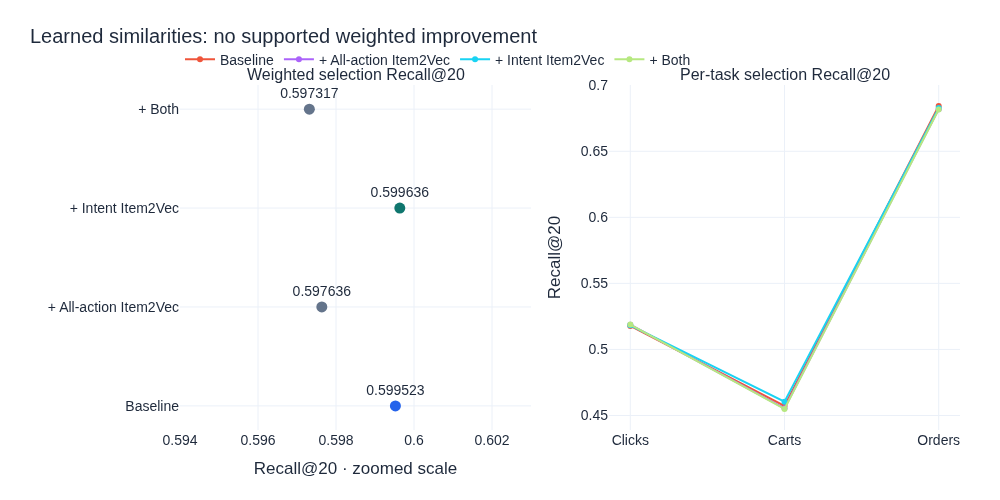

,Arm,Weighted Recall@20
0,Baseline,0.599523
1,+ All-action Item2Vec,0.597636
2,+ Both,0.597317
3,+ Intent Item2Vec,0.599636


In [13]:
representation_path = ROOT / 'reports/research/representation_results.json'
assert hashlib.sha256(representation_path.read_bytes()).hexdigest() == '7e5f5fc004a89e87d104506c94228b6d5c9a19de315747ffdb510c58ea0635ae'
representation = json.loads(representation_path.read_text())
assert representation['status'] == 'passed'
rows = representation['variants']
labels = {'baseline': 'Baseline', 'with_all': '+ All-action Item2Vec',
          'with_intent': '+ Intent Item2Vec', 'with_both': '+ Both'}
fig = make_subplots(rows=1, cols=2, subplot_titles=['Weighted selection Recall@20', 'Per-task selection Recall@20'])
for arm, label in labels.items():
    values = rows[arm]
    color = COLORS['core'] if arm == 'baseline' else COLORS['selected'] if arm == 'with_intent' else COLORS['fusion']
    fig.add_scatter(x=[values['weighted_recall_at_20']], y=[label], mode='markers+text',
        text=[f"{values['weighted_recall_at_20']:.6f}"], textposition='top center',
        marker=dict(size=11, color=color), name=label, showlegend=False, row=1, col=1)
    fig.add_scatter(x=['Clicks', 'Carts', 'Orders'],
        y=[values['objectives'][o]['recall_at_20'] for o in ('clicks', 'carts', 'orders')],
        mode='lines+markers', name=label, row=1, col=2)
fig.update_xaxes(range=[.594, .603], title_text='Recall@20 · zoomed scale', row=1, col=1)
fig.update_yaxes(title_text='Recall@20', row=1, col=2)
show(fig, 'Learned similarities: no supported weighted improvement', height=500, left=180)
display(pd.DataFrame([{'Arm': labels[k], 'Weighted Recall@20': v['weighted_recall_at_20']}
                     for k,v in rows.items()]).style.format({'Weighted Recall@20': '{:.6f}'}))
